In [19]:
from econdatapy import read
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
usdzar = read.dataset(
  id = "MARKET_RATES",
  version = "1.0.0",
  series_key = "EXCX135.B.A",
  release = "ZARIBOR & ZARONIA")

Fetching dataset(s) - MARKET_RATES

Processing data set: ECONDATA-MARKET_RATES-1.0.0



In [30]:
usdzar_data = usdzar['data']
df = usdzar_data['EXCX135.B.A'].copy()

# Parse dates and set as index
df['TIME_PERIOD'] = pd.to_datetime(df['TIME_PERIOD'])
df = df.set_index('TIME_PERIOD').sort_index()

# --- 2. Filter to Jan 2022 onward ---
df = df.loc['2010-01-01':]

full_price = df['OBS_VALUE'].dropna()
train_price = full_price.loc['2010-01-01':'2020-12-31']
actual_price = full_price.loc['2021-01-01':'2025-12-31']

print(f"Training on {len(train_price)} obs: {train_price.index.min().date()} to {train_price.index.max().date()}")
print(f"Evaluating against {len(actual_price)} obs: {actual_price.index.min().date()} to {actual_price.index.max().date()}")

Training on 2749 obs: 2010-01-04 to 2020-12-31
Evaluating against 1248 obs: 2021-01-04 to 2025-12-31


In [36]:
origins = pd.date_range('2021-01-01', '2025-12-01', freq='MS')  # month start = forecast origin
results = []

In [38]:
for origin in origins:
    # Trailing window = the previous month's true values, ending just before/at origin
    window_start = origin - pd.DateOffset(months=1)
    train_window = price.loc[window_start:origin]

    if len(train_window) < 5:  # not enough data to estimate returns, skip
        continue

    # Estimate drift/vol from ONLY the previous month's true observations
    log_returns = np.log(train_window / train_window.shift(1)).dropna()
    mu = log_returns.mean()
    sigma = log_returns.std()

    # Anchor forecast on the last TRUE value at the origin (not a prior forecast)
    last_true_price = train_window.iloc[-1]
    last_true_date = train_window.index[-1]

    # Forecast target: 1 month ahead of the origin
    target_date = origin + pd.DateOffset(months=1)

    # Find the closest actual observation to the target date (real trading day)
    future_slice = price.loc[target_date:]
    if future_slice.empty:
        continue
    actual_date = future_slice.index[0]
    actual_value = future_slice.iloc[0]

    # Trading days between origin and actual forecasted date (for drift compounding)
    horizon_days = (price.loc[last_true_date:actual_date]).shape[0] - 1
    if horizon_days <= 0:
        continue

    naive_forecast = last_true_price
    drift_forecast = last_true_price * np.exp(mu * horizon_days)

    results.append({
        'origin': origin,
        'last_true_date': last_true_date,
        'last_true_price': last_true_price,
        'target_date': actual_date,
        'actual_value': actual_value,
        'naive_forecast': naive_forecast,
        'drift_forecast': drift_forecast,
        'mu': mu,
        'sigma': sigma,
        'horizon_days': horizon_days,
    })

results_df = pd.DataFrame(results).set_index('origin')

In [33]:
n_sims = 1000
np.random.seed(1)

simulated_log_returns = np.random.normal(loc=mu, scale=sigma, size=(n_sims, horizon))
simulated_log_paths = np.cumsum(simulated_log_returns, axis=1)
simulated_price_paths = last_price * np.exp(simulated_log_paths)

sim_mean = pd.Series(simulated_price_paths.mean(axis=0), index=future_index)
sim_lower = pd.Series(np.percentile(simulated_price_paths, 5, axis=0), index=future_index)
sim_upper = pd.Series(np.percentile(simulated_price_paths, 95, axis=0), index=future_index)

In [39]:
def rmse(forecast, actual):
    return np.sqrt(np.mean((forecast - actual) ** 2))

print(f"RMSE naive RW (rolling, prior month anchor): {rmse(results_df['naive_forecast'], results_df['actual_value']):.4f}")
print(f"RMSE RW with drift (rolling, prior month):    {rmse(results_df['drift_forecast'], results_df['actual_value']):.4f}")

RMSE naive RW (rolling, prior month anchor): 0.5461
RMSE RW with drift (rolling, prior month):    0.8160


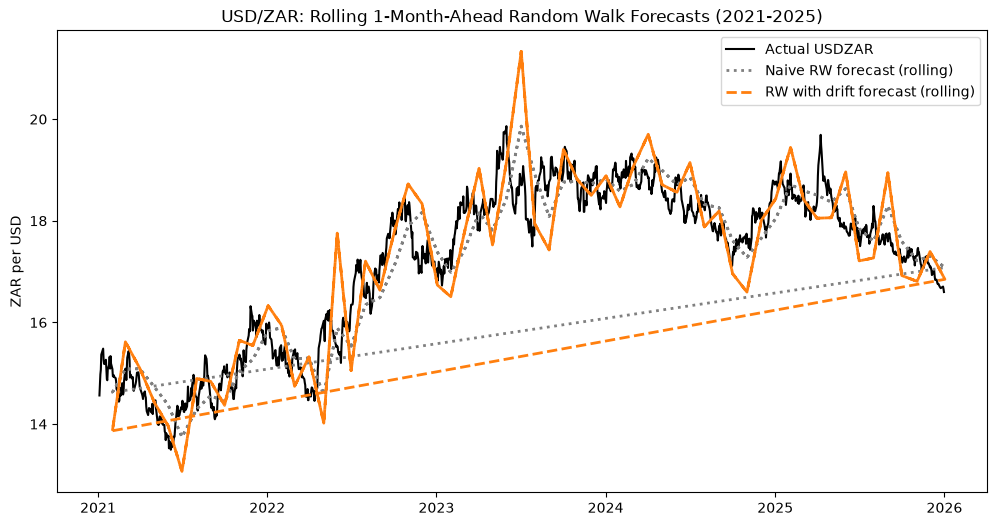

In [43]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(price.loc['2021-01-01':'2025-12-31'].index,
        price.loc['2021-01-01':'2025-12-31'].values,
        label="Actual USDZAR", color="black", linewidth=1.5, linestyle='-')

ax.plot(results_df['target_date'], results_df['naive_forecast'],
        label="Naive RW forecast (rolling)", color="gray", linestyle=':', linewidth=2)

ax.plot(results_df['target_date'], results_df['drift_forecast'],
        label="RW with drift forecast (rolling)", color="tab:orange", linestyle='--', linewidth=2)

ax.legend()
ax.set_title("USD/ZAR: Rolling 1-Month-Ahead Random Walk Forecasts (2021-2025)")
ax.set_ylabel("ZAR per USD")

plt.show()

In [42]:
results_df.head(10)

,last_true_date,last_true_price,target_date,actual_value,naive_forecast,drift_forecast,mu,sigma,horizon_days
origin,,,,,,,,,
2021-01-01,2020-12-31,14.6246,2021-02-01,15.0809,14.6246,13.867352,-0.002532,0.007338,21
2021-02-01,2021-02-01,15.0809,2021-03-01,15.0894,15.0809,15.617647,0.001749,0.011154,20
2021-03-01,2021-03-01,15.0894,2021-04-01,14.7241,15.0894,15.098756,0.000028,0.009473,22
2021-04-01,2021-04-01,14.7241,2021-05-03,14.4599,14.7241,14.415738,-0.001114,0.009346,19
2021-05-01,2021-04-30,14.3799,2021-06-01,13.7467,14.3799,13.970119,-0.001314,0.007579,22
2021-06-01,2021-06-01,13.7467,2021-07-01,14.2968,13.7467,13.068677,-0.002409,0.006642,21
2021-07-01,2021-07-01,14.2968,2021-08-02,14.5165,14.2968,14.896721,0.001868,0.010313,22
2021-08-01,2021-07-30,14.5593,2021-09-01,14.4419,14.5593,14.839471,0.000866,0.010127,22
2021-09-01,2021-09-01,14.4419,2021-10-01,15.0323,14.4419,14.367683,-0.000245,0.010307,21
